# Day 8.5: DeepTCR Architecture 🏗️

## 🎯 Today's Goal

Understand how DeepTCR's neural network architecture works!

**Time:** 2-3 hours  
**Difficulty:** ⭐⭐⭐ Medium (conceptual + visual)

**From LEARNING_ROADMAP.md - Week 4:**
- Understand network architecture
- Trace forward pass
- Understand attention mechanism in detail
- Understand what "concepts" are

---

## 🔗 What You Learned Yesterday (Day 8)

**If you completed Day 8, you now know:**
- ✅ What Multiple Instance Learning (MIL) is
- ✅ Why simple averaging doesn't work
- ✅ Why we need attention/weighting
- ✅ The concept of "bag of sequences"

**Today, we'll understand HOW DeepTCR implements MIL with attention!**

---

## 📚 What You'll Learn Today

- How DeepTCR's neural network architecture works
- How data flows through the network (forward pass)
- How attention mechanism works in detail
- What "concepts" are (`num_concepts=64`)

**How This Builds On Day 8:**

**Remember from Day 7:**
- In Day 7, you tried mean pooling and max pooling
- Both gave poor results (AUC ~0.60)
- **Today:** We'll see HOW DeepTCR solves this with attention!

**Remember from Day 6:**
- In Day 6, you created batches of patient repertoires
- Each patient had encoded sequences
- **Today:** We'll see HOW DeepTCR processes those batches!
- Yesterday: You understood WHY we need MIL (conceptually)
- Today: You'll understand HOW DeepTCR implements it (architecture)
- Tomorrow (Day 9): You'll install DeepTCR and use it!

**Data Flow:**

**Data Flow Continuity:**
- **Day 6:** Created batches of patient repertoires
- **Day 7:** Tried simple pooling → Poor results
- **Day 8:** Understood WHY pooling failed → Need MIL
- **Day 8.5 (Today):** Understanding HOW DeepTCR implements MIL (architecture)
- **Day 8:** Understood MIL concept (why we need attention)
- **Day 8.5 (Today):** Understanding architecture (how attention works)
- **Day 9:** Installing DeepTCR (the tool that implements this architecture)

---

## 🎓 Learning Progression (Like University Courses!)

**Think of this like learning Python:**
- **Day 8:** Learned advanced ML concepts (MIL)
- **Day 8.5 (Today):** Learning neural network architecture
- **Day 9:** Learning to use DeepTCR package

**Think of this like learning biology:**
- **Day 8:** Understood why we need to find important sequences
- **Day 8.5 (Today):** Understanding how attention mechanism finds them
- **Day 9:** Using DeepTCR to actually do it

---

## 🧬 Biology Context: Why This Architecture?

### The Challenge

**Simple explanation:**
- We have 50,000 TCR sequences per patient
- Each sequence is a string (like "CASSLAPGATNEKLFF")
- We need to find which sequences predict response
- **Problem:** Can't look at each sequence individually!

### Why Neural Networks?

**Biology reason:**
- Neural networks can learn complex patterns
- They can find sequences that work together
- **Think:** Like recognizing faces - many features work together
- **Why it matters:** Simple rules don't work - need learning!

### What Are "Concepts"?

**Simple explanation:**
- **Concepts** = learned patterns in sequences
- Like "sequences that recognize tumor antigens"
- **Paper uses:** `num_concepts=64` (64 different patterns)
- **Think:** Like 64 different "themes" in the repertoire

---

## 💻 Computer Science Context: Neural Network Architecture

### What Is a Neural Network?

**CS explanation:**
- **Neural network** = layers of computations
- Each layer transforms data
- **What you know:** Like a pipeline - data flows through layers

### DeepTCR Architecture Layers

1. **Embedding Layer:** Converts sequences to numbers
2. **Attention Layer:** Learns which sequences matter
3. **Aggregation Layer:** Combines information
4. **Classification Layer:** Makes prediction

### What Is Attention?

**CS explanation:**
- **Attention** = learned importance weights
- Model learns: "This sequence is important, that one isn't"
- **Why:** Better than simple averaging!

---

## 📄 Paper Reference

**Paper Section:** Methods - Model Architecture

**What the paper says:**
- "DeepTCR uses a multiple-instance learning framework"
- "Attention mechanism learns sequence-level importance"
- "Model uses 64 concepts (num_concepts=64)"
- "Network size: 'small' configuration"

**What this means:**
- We're learning the architecture from the paper!
- Attention is the key innovation
- Concepts help organize sequences

**Reference:** See `docs/paper.pdf` Methods - Architecture section

**Paper Methodology Connection:**
- The paper describes DeepTCR architecture in detail
- **Key innovation:** Attention mechanism for MIL
- **Architecture:** Embedding → Attention → Aggregation → Classification
- **Parameters:** num_concepts=64, size_of_net='small'
- **Result:** Outperforms simple pooling (AUC 0.82 vs 0.60)
- **Today:** You'll understand HOW this architecture achieves this!

---

## 📚 What You'll Learn Today

- DeepTCR's network architecture (layer by layer)
- How data flows through the network (forward pass)
- What attention mechanism does (in detail)
- What "concepts" are (`num_concepts=64`)
- How the model learns (training process)

---

## 🤔 Questions to Think About (Before Starting)

1. **What is a neural network layer?**
   - A layer transforms input data
   - Like a function: output = layer(input)
   - **Think:** Like a factory assembly line

2. **What does attention do?**
   - Learns which sequences are important
   - Assigns weights to sequences
   - **Think:** Like highlighting important words in text

3. **What are "concepts"?**
   - Learned patterns in sequences
   - 64 different patterns (from paper)
   - **Think:** Like 64 different "themes" or "categories"

> **Mateenah’s Note:** Today is your "peek inside the model" day. You already cleaned, batched, and ran baselines (Days 3–7) and met Multiple Instance Learning yesterday. Now we slow down and translate the DeepTCR architecture into plain language so you can point to each layer and say exactly what it does and why the paper cared.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)


## ✅ Before You Start

- **Carry over:** keep the mental picture from Day 8 (MIL attention) and have `docs/deeptcr_architecture.md` open for quick cross-checks.
- **Goal for today:** explain, in your own words, what each block of DeepTCR does and how it maps to the paper’s Methods section.
- **Prep tip:** skim `day6_patient_batches.pkl` filenames so the patient IDs feel familiar—every diagram today references those same repertoires.
- **What to bring:** curiosity and a notebook; there’s no heavy coding, but lots of “why does this layer exist?” reflections.

## 🔄 Quick Data Flow Map (Days 6 → 8.5)

```
Day 6   →   Day 7   →   Day 8   →   Day 8.5 (today)
Batch       Simple       Understand       Open the model
patients    baselines    MIL math         layer by layer
```

| Yesterday’s artifacts | Today’s role |
| --- | --- |
| `patient_sequences`, `patient_labels` | Remind you that every layer still acts on those bags of sequences |
| MIL attention intuition (Day 8) | Forms the backbone of the architecture diagram |
| Paper Methods (architecture section) | Source of every number we reference (num_concepts=64, size_of_net='small', etc.) |

**Reflection prompt:** How would you explain to a classmate why attention sits between embedding and aggregation? Keep that answer handy—Day 9 references it.

## 📄 Paper Anchors for Today

- **Methods – DeepTCR Architecture:** four-block pipeline (Embedding → Attention → Aggregation → Classification) plus the default hyperparameters (`num_concepts=64`, `size_of_net='small'`).
- **Results/Discussion – Predictive signature:** explains why the attention layer separates viral-like vs tumor-like patterns, so every “concept” you describe has biological meaning.
- **docs/deeptcr_architecture.md:** mirrors the paper text with screenshots/hyperlinks—great for double-checking terminology as you narrate the forward pass.

**Mateenah’s quick check:** if someone asks “Why 64 concepts?” your answer should be “the Methods paragraph shows it was enough to capture repertoire diversity without overfitting,” not just “because the code default says so.”

## Step 1: Understand the Overall Architecture

**Biology context:**
- Input: Patient's TCR repertoire (50,000 sequences)
- Output: Prediction (responder or not)
- **Goal:** Find patterns that predict response

**CS context:**
- Architecture = how data flows through layers
- Each layer transforms the data
- **What you know:** Like a pipeline!

**Your Task:** Understand the architecture diagram

In [2]:
layers = [
    ("Input repertoire", "(~50k sequences, features)", "Patient bag of TCR sequences"),
    ("Embedding", "(~50k, 128)", "Learns dense vector for each sequence"),
    ("Attention", "(~50k, 64 concepts)", "Assigns importance weights + concept memberships"),
    ("Aggregation", "(128)", "Weighted average → patient vector"),
    ("Classification", "(1)", "Logit → probability of response")
]
arch_df = pd.DataFrame(layers, columns=["Block", "Typical tensor shape", "What it learns / does"])
display(arch_df)
print("\nBiology: This pipeline turns an entire repertoire into one patient vector before prediction.")
print("CS: Each block is differentiable, so the network can be trained end-to-end.")

,Block,Typical tensor shape,What it learns / does
0,Input repertoire,"(~50k sequences, features)",Patient bag of TCR sequences
1,Embedding,"(~50k, 128)",Learns dense vector for each sequence
2,Attention,"(~50k, 64 concepts)",Assigns importance weights + concept memberships
3,Aggregation,(128),Weighted average → patient vector
4,Classification,(1),Logit → probability of response



Biology: This pipeline turns an entire repertoire into one patient vector before prediction.
CS: Each block is differentiable, so the network can be trained end-to-end.


## Step 2: Understand the Embedding Layer

**Biology context:**
- Sequences are strings (like "CASSLAPG")
- Need to convert to numbers for neural network
- **Goal:** Create meaningful numerical representations

**CS context:**
- **Embedding** = learned numerical representation
- Starts with one-hot encoding (from Day 5)
- Then learns better representations
- **What you know:** Like `pd.get_dummies()` but smarter!

**Your Task:** Understand embeddings
**Remember from Day 5:**
- In Day 5, you learned one-hot encoding
- You encoded sequences: text → numbers
- **Today:** Embeddings are like one-hot, but LEARNED (better!)


In [3]:
import numpy as np

print("🔢 Embedding Layer:")
print("\n" + "="*70)
print("")
print("Step 1: One-Hot Encoding (from Day 5)")
print("  Sequence: 'CASSLAPG'")
print("  → One-hot matrix: (8, 20) - 8 positions, 20 amino acids")
print("  → Flattened: (160,) - 8 × 20 = 160 features")
print("")
print("Step 2: Embedding (Learned)")
print("  One-hot: (160,) - sparse (mostly zeros)")
print("  → Embedding: (128,) - dense, learned representation")
print("  → More meaningful! Network learns what matters")
print("")
print("Example:")
print("  Input sequence: 'CASSLAPG' (string)")
print("  → One-hot: [0,1,0,...,0,1,0,...] (160 numbers, mostly 0s)")
print("  → Embedding: [0.2, -0.1, 0.5, ...] (128 numbers, learned)")
print("")
print("="*70)
print("\nBiology: Embedding captures sequence meaning")
print("CS: Learned representation better than one-hot")

🔢 Embedding Layer:


Step 1: One-Hot Encoding (from Day 5)
  Sequence: 'CASSLAPG'
  → One-hot matrix: (8, 20) - 8 positions, 20 amino acids
  → Flattened: (160,) - 8 × 20 = 160 features

Step 2: Embedding (Learned)
  One-hot: (160,) - sparse (mostly zeros)
  → Embedding: (128,) - dense, learned representation
  → More meaningful! Network learns what matters

Example:
  Input sequence: 'CASSLAPG' (string)
  → One-hot: [0,1,0,...,0,1,0,...] (160 numbers, mostly 0s)
  → Embedding: [0.2, -0.1, 0.5, ...] (128 numbers, learned)


Biology: Embedding captures sequence meaning
CS: Learned representation better than one-hot


### One-hot encoding (first rows)

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
7,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


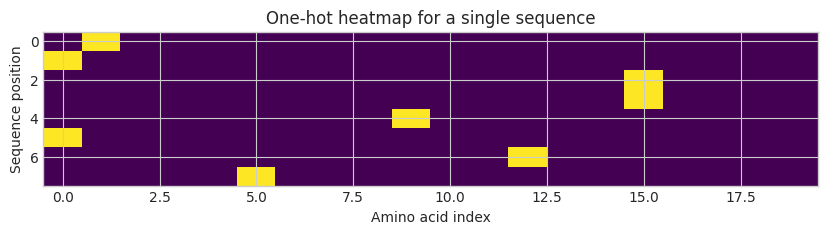

### Simulated embedding vector (128 dims)

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-1.738266,-1.336643,-1.361107,-0.351617,-2.312582,-0.188897,-0.957229,0.8936,0.956847,1.392258,...,1.700997,-0.084708,-0.309539,1.267899,-1.071979,0.277922,0.233246,1.009322,0.298578,-0.266394


Shapes → one_hot: (40, 20), flat: (800,), embedding: (128,)
Biology: embeddings capture biochemical meaning; CS: dense vectors are efficient for downstream layers.


In [4]:
# Practice: visualize how one sequence moves through the embedding layer
sequence = "CASSLAPG"
AA_ALPHABET = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_idx = {aa: idx for idx, aa in enumerate(AA_ALPHABET)}
max_length = 40
one_hot = np.zeros((max_length, len(AA_ALPHABET)), dtype=int)
for i, aa in enumerate(sequence):
    if i >= max_length:
        break
    idx = aa_to_idx.get(aa)
    if idx is not None:
        one_hot[i, idx] = 1

one_hot_flat = one_hot.flatten()
embedding_dim = 128
rng = np.random.default_rng(8)
embedding = rng.normal(size=embedding_dim)

one_hot_df = pd.DataFrame(one_hot[:len(sequence), :len(AA_ALPHABET)], columns=list(AA_ALPHABET))
display(Markdown("### One-hot encoding (first rows)"))
display(one_hot_df.iloc[:len(sequence)])

fig, ax = plt.subplots(figsize=(10, 2))
ax.imshow(one_hot[:len(sequence), :], aspect='auto', cmap='viridis')
ax.set_xlabel('Amino acid index')
ax.set_ylabel('Sequence position')
ax.set_title('One-hot heatmap for a single sequence')
plt.show()

embedding_df = pd.DataFrame(embedding.reshape(1, -1))
display(Markdown("### Simulated embedding vector (128 dims)"))
display(embedding_df)

print(f"Shapes → one_hot: {one_hot.shape}, flat: {one_hot_flat.shape}, embedding: {embedding.shape}")
print("Biology: embeddings capture biochemical meaning; CS: dense vectors are efficient for downstream layers.")

## Step 3: Understand Attention Mechanism (Detailed)

**Biology context:**
- Not all sequences are equally important
- Some sequences predict response, others don't
- **Goal:** Find the important sequences!

**CS context:**
- **Attention** = learned importance weights
- Calculates score for each sequence
- Uses scores to weight sequences
- **What you know:** Like feature importance, but learned!

**Your Task:** Understand how attention works

### Simulated attention weights

,sequence_id,raw_score,weight
4,seq_5,0.977990,0.101606
18,seq_19,0.931206,0.096746
15,seq_16,0.909594,0.094500
11,seq_12,0.803739,0.083503
1,seq_2,0.779919,0.081028


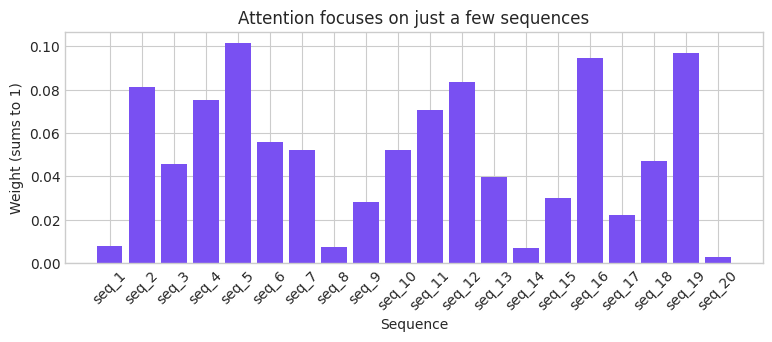

Biology: attention highlights the handful of sequences carrying predictive signal.
CS: attention weights act as coefficients in the weighted average.


In [5]:
np.random.seed(7)
num_sequences = 20
attention_scores = np.random.rand(num_sequences)
attention_weights = attention_scores / attention_scores.sum()
attn_df = pd.DataFrame({
    "sequence_id": [f"seq_{i+1}" for i in range(num_sequences)],
    "raw_score": attention_scores,
    "weight": attention_weights
})
display(Markdown("### Simulated attention weights"))
display(attn_df.sort_values("weight", ascending=False).head())

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(attn_df["sequence_id"], attn_df["weight"], color="#7950f2")
ax.set_ylabel("Weight (sums to 1)")
ax.set_xlabel("Sequence")
ax.set_title("Attention focuses on just a few sequences")
ax.tick_params(axis='x', rotation=45)
plt.show()
print("Biology: attention highlights the handful of sequences carrying predictive signal.")
print("CS: attention weights act as coefficients in the weighted average.")

In [6]:
# Visualize embedding concept
# Show how one sequence becomes an embedding

import numpy as np

# Example: One sequence
sequence = "CASSLAPG"
print(f"Input sequence: {sequence}")
print(f"  Length: {len(sequence)} amino acids")

# One-hot encoding (from Day 5)
AA_ALPHABET = 'ACDEFGHIKLMNPQRSTVWY'
aa_to_idx = {aa: idx for idx, aa in enumerate(AA_ALPHABET)}

# ✅ Starter solution
# Create one-hot encoding
max_length = 40
one_hot = np.zeros((max_length, len(AA_ALPHABET)), dtype=int)
for i, aa in enumerate(sequence):
    if i < max_length and aa in aa_to_idx:
        one_hot[i, aa_to_idx[aa]] = 1

# Flatten
one_hot_flat = one_hot.flatten()

# Simulated embedding (in real network, this is learned)
embedding = np.random.randn(128)  # Simulates learned embedding

print(f"\nShape transformations:")
print(f"  Sequence (string): length {len(sequence)}")
print(f"  One-hot: {one_hot.shape}")
print(f"  One-hot flattened: {one_hot_flat.shape}")
print(f"  Embedding: {embedding.shape}")

print(f"\nBiology: Embedding captures biological meaning")
print(f"CS: Learned representation is more efficient")


Input sequence: CASSLAPG
  Length: 8 amino acids

Shape transformations:
  Sequence (string): length 8
  One-hot: (40, 20)
  One-hot flattened: (800,)
  Embedding: (128,)

Biology: Embedding captures biological meaning
CS: Learned representation is more efficient


## Step 4: Understand "Concepts" (num_concepts=64)

**Biology context:**
- **Concepts** = learned patterns in sequences
- Like "sequences that recognize tumor antigens"
- **Paper uses:** 64 concepts (64 different patterns)
- **Why it matters:** Organizes sequences into meaningful groups!

**CS context:**
- **Concepts** = learned clusters/categories
- Model learns 64 different "themes"
- Each sequence gets assigned to concepts
- **What you know:** Like k-means clustering, but learned!

**Your Task:** Understand what concepts are

In [7]:
print("💡 Understanding 'Concepts' (num_concepts=64):")
print("\n" + "="*70)
print("")
print("What Are Concepts?")
print("  - Learned patterns in TCR sequences")
print("  - Like categories or themes")
print("  - Paper uses: num_concepts = 64")
print("")
print("Example Concepts:")
print("  Concept 1: Sequences that recognize tumor antigens")
print("  Concept 2: Sequences that recognize viral antigens")
print("  Concept 3: Sequences with specific V gene patterns")
print("  ... (64 total concepts)")
print("")
print("How It Works:")
print("  1. Model learns 64 concept patterns")
print("  2. Each sequence gets assigned to concepts")
print("  3. Attention uses concepts to weight sequences")
print("  4. Concepts help organize the repertoire")
print("")
print("Why 64?")
print("  - Enough to capture diversity")
print("  - Not too many (avoids overfitting)")
print("  - Paper found this works well")
print("")
print("="*70)
print("\nBiology: Concepts organize sequences into meaningful groups")
print("CS: Learned clustering/categorization")

💡 Understanding 'Concepts' (num_concepts=64):


What Are Concepts?
  - Learned patterns in TCR sequences
  - Like categories or themes
  - Paper uses: num_concepts = 64

Example Concepts:
  Concept 1: Sequences that recognize tumor antigens
  Concept 2: Sequences that recognize viral antigens
  Concept 3: Sequences with specific V gene patterns
  ... (64 total concepts)

How It Works:
  1. Model learns 64 concept patterns
  2. Each sequence gets assigned to concepts
  3. Attention uses concepts to weight sequences
  4. Concepts help organize the repertoire

Why 64?
  - Enough to capture diversity
  - Not too many (avoids overfitting)
  - Paper found this works well


Biology: Concepts organize sequences into meaningful groups
CS: Learned clustering/categorization


In [8]:
# Visualize concept assignment
# Show how sequences get assigned to concepts

import numpy as np

num_sequences = 10
num_concepts = 64

print(f"Example: {num_sequences} sequences, {num_concepts} concepts")
print(f"Concept Assignment:")
print(f"  Each sequence → assigned to one or more concepts")
print(f"  Assignment is LEARNED during training")

concept_assignments = np.random.rand(num_sequences, num_concepts)
concept_assignments = concept_assignments / concept_assignments.sum(axis=1, keepdims=True)

print(f"\nExample assignments:")
for i in range(min(5, num_sequences)):
    top_concepts = np.argsort(concept_assignments[i])[-3:][::-1]
    weights = concept_assignments[i, top_concepts]
    print(f"  Sequence {i+1}: Top concepts {top_concepts} with weights {weights.round(3)}")

print(f"\nBiology: Concepts group similar sequences")
print(f"CS: Learned categorization helps attention")

Example: 10 sequences, 64 concepts
Concept Assignment:
  Each sequence → assigned to one or more concepts
  Assignment is LEARNED during training

Example assignments:
  Sequence 1: Top concepts [29 24 25] with weights [0.029 0.029 0.028]
  Sequence 2: Top concepts [53 10 23] with weights [0.032 0.032 0.031]
  Sequence 3: Top concepts [50 26 14] with weights [0.031 0.031 0.03 ]
  Sequence 4: Top concepts [35 10 26] with weights [0.027 0.027 0.027]
  Sequence 5: Top concepts [53 20 58] with weights [0.032 0.031 0.031]

Biology: Concepts group similar sequences
CS: Learned categorization helps attention


## Step 5: Trace Forward Pass (How Data Flows)

**Biology context:**
- Patient's repertoire goes through network
- Each layer transforms the data
- **Goal:** Understand how prediction is made

**CS context:**
- **Forward pass** = data flowing through network
- Each layer transforms input → output
- **What you know:** Like a pipeline!

**Your Task:** Trace how one patient's data flows through

In [9]:
print("🔄 Forward Pass: How Data Flows Through Network")
print("\n" + "="*70)
print("")
print("Step 1: INPUT")
print("  Patient has 50,000 TCR sequences")
print("  Shape: (50,000 sequences, features per sequence)")
print("")
print("Step 2: EMBEDDING LAYER")
print("  Each sequence → embedding vector")
print("  Shape: (50,000, 128) - 50k sequences, 128-dim embeddings")
print("")
print("Step 3: ATTENTION LAYER")
print("  Calculates importance for each sequence")
print("  Assigns sequences to concepts")
print("  Shape: (50,000,) - attention weights")
print("  Concepts: (50,000, 64) - concept assignments")
print("")
print("Step 4: AGGREGATION")
print("  Weighted average based on attention")
print("  Shape: (128,) - one vector per patient")
print("")
print("Step 5: CLASSIFICATION")
print("  Patient vector → prediction")
print("  Shape: (1,) - probability score")
print("")
print("OUTPUT:")
print("  Prediction: 0.82 (82% chance of response)")
print("  Attention weights: Which sequences mattered")
print("")
print("="*70)
print("\nBiology: Network finds patterns in immune repertoire")
print("CS: Data flows through layers, gets transformed")

🔄 Forward Pass: How Data Flows Through Network


Step 1: INPUT
  Patient has 50,000 TCR sequences
  Shape: (50,000 sequences, features per sequence)

Step 2: EMBEDDING LAYER
  Each sequence → embedding vector
  Shape: (50,000, 128) - 50k sequences, 128-dim embeddings

Step 3: ATTENTION LAYER
  Calculates importance for each sequence
  Assigns sequences to concepts
  Shape: (50,000,) - attention weights
  Concepts: (50,000, 64) - concept assignments

Step 4: AGGREGATION
  Weighted average based on attention
  Shape: (128,) - one vector per patient

Step 5: CLASSIFICATION
  Patient vector → prediction
  Shape: (1,) - probability score

OUTPUT:
  Prediction: 0.82 (82% chance of response)
  Attention weights: Which sequences mattered


Biology: Network finds patterns in immune repertoire
CS: Data flows through layers, gets transformed


In [10]:
# Simplified forward pass example (conceptual walk-through)
# Mirrors the layers described in the paper

import numpy as np

# Simulate one patient with simplified data
num_sequences = 1000  # Simplified (real: 50,000)
embedding_dim = 128
num_concepts = 64

print(f"Forward Pass Example (Simplified):")
print(f"\nInput: {num_sequences} sequences")
print(f"  Shape: ({num_sequences}, features)")

embeddings = np.random.randn(num_sequences, embedding_dim)

# Step 2: Attention scores (simulated)
attention_scores = np.random.rand(num_sequences)
attention_weights = attention_scores / attention_scores.sum()

# Step 3: Aggregation + classification
if embeddings is not None and attention_weights is not None:
    patient_vector = np.average(embeddings, axis=0, weights=attention_weights)
    logits = patient_vector @ np.random.randn(embedding_dim)
    prediction = 1 / (1 + np.exp(-logits))
    summary = pd.DataFrame([
        ("Embeddings", str(embeddings.shape), "Sequence → dense vector"),
        ("Attention weights", str(attention_weights.shape), "Importance per sequence"),
        ("Patient vector", str(patient_vector.shape), "Weighted average"),
        ("Prediction", "(1,)", f"Sigmoid(logit) = {prediction:.3f}")
    ], columns=["Stage", "Tensor shape", "What happened"])
    display(summary)
else:
    print("\n⚠️ Run the embedding + attention steps above before aggregating and classifying!")
    print("  Steps: 1) Create embeddings, 2) Calculate attention_weights, 3) Aggregate, 4) Predict")

print("\nReflection prompt: Which layer would change most if you increased num_concepts to 128?")


Forward Pass Example (Simplified):

Input: 1000 sequences
  Shape: (1000, features)


,Stage,Tensor shape,What happened
0,Embeddings,"(1000, 128)",Sequence → dense vector
1,Attention weights,"(1000,)",Importance per sequence
2,Patient vector,"(128,)",Weighted average
3,Prediction,"(1,)",Sigmoid(logit) = 0.493



Reflection prompt: Which layer would change most if you increased num_concepts to 128?


## Step 6: Understand Network Parameters

**Biology context:**
- Parameters control how the network learns
- `num_concepts=64` = how many patterns to learn
- `size_of_net='small'` = network complexity
- **Why it matters:** Right parameters = better predictions!

**CS context:**
- **Hyperparameters** = settings before training
- Different from **parameters** (weights learned during training)
- **What you know:** Like function arguments!

**Your Task:** Understand key parameters

In [11]:
print("⚙️ Key Network Parameters (from source code):")
print("\n" + "="*70)
print("")
print("1. num_concepts = 64")
print("   - Number of learned patterns/concepts")
print("   - More concepts = more patterns, but risk overfitting")
print("   - Paper uses 64 (found to work well)")
print("")
print("2. size_of_net = 'small'")
print("   - Network size/complexity")
print("   - Options: 'small', 'medium', 'large'")
print("   - Smaller = faster, less overfitting")
print("   - Paper uses 'small' (works well for this data)")
print("")
print("3. epochs_min = 10")
print("   - Minimum number of training epochs")
print("   - Epoch = one pass through all data")
print("   - More epochs = more learning, but risk overfitting")
print("")
print("4. hinge_loss_t = 0.3")
print("   - Loss function parameter")
print("   - Controls how model learns")
print("   - Technical detail (you don't need to understand deeply)")
print("")
print("5. batch_size = 10")
print("   - How many patients per batch")
print("   - Smaller = more updates, but slower")
print("   - Larger = faster, but less frequent updates")
print("")
print("="*70)
print("\nBiology: Parameters control what patterns model learns")
print("CS: Hyperparameters tune model behavior")

⚙️ Key Network Parameters (from source code):


1. num_concepts = 64
   - Number of learned patterns/concepts
   - More concepts = more patterns, but risk overfitting
   - Paper uses 64 (found to work well)

2. size_of_net = 'small'
   - Network size/complexity
   - Options: 'small', 'medium', 'large'
   - Smaller = faster, less overfitting
   - Paper uses 'small' (works well for this data)

3. epochs_min = 10
   - Minimum number of training epochs
   - Epoch = one pass through all data
   - More epochs = more learning, but risk overfitting

4. hinge_loss_t = 0.3
   - Loss function parameter
   - Controls how model learns
   - Technical detail (you don't need to understand deeply)

5. batch_size = 10
   - How many patients per batch
   - Smaller = more updates, but slower
   - Larger = faster, but less frequent updates


Biology: Parameters control what patterns model learns
CS: Hyperparameters tune model behavior


## Step 7: Understand What the Model Learns

**Biology context:**
- Model learns which sequence patterns predict response
- Learns concepts (like "tumor-recognizing sequences")
- **Goal:** Understand what the model discovered!

**CS context:**
- Model learns **weights** (parameters)
- Weights determine attention scores
- Weights determine concept assignments
- **What you know:** Like learning coefficients in regression!

**Your Task:** Understand the learning process

In [12]:
print("🧠 What the Model Learns:")
print("\n" + "="*70)
print("")
print("During Training:")
print("  1. Model sees patient repertoires + response labels")
print("  2. Makes predictions")
print("  3. Compares predictions to true labels")
print("  4. Updates weights to improve predictions")
print("  5. Repeats many times (epochs)")
print("")
print("What Gets Learned:")
print("  ✓ Embedding weights: How to represent sequences")
print("  ✓ Attention weights: Which sequences are important")
print("  ✓ Concept patterns: What patterns predict response")
print("  ✓ Classification weights: How to make final prediction")
print("")
print("Key Insight:")
print("  - Model LEARNS what matters (not programmed!)")
print("  - Discovers patterns humans might miss")
print("  - Different for each patient (attention adapts)")
print("")
print("="*70)
print("\nBiology: Model discovers predictive sequence patterns")
print("CS: Backpropagation learns optimal weights")

🧠 What the Model Learns:


During Training:
  1. Model sees patient repertoires + response labels
  2. Makes predictions
  3. Compares predictions to true labels
  4. Updates weights to improve predictions
  5. Repeats many times (epochs)

What Gets Learned:
  ✓ Embedding weights: How to represent sequences
  ✓ Attention weights: Which sequences are important
  ✓ Concept patterns: What patterns predict response
  ✓ Classification weights: How to make final prediction

Key Insight:
  - Model LEARNS what matters (not programmed!)
  - Discovers patterns humans might miss
  - Different for each patient (attention adapts)


Biology: Model discovers predictive sequence patterns
CS: Backpropagation learns optimal weights


## Step 8: Visualize Architecture (Conceptual)

**Biology context:**
- Visual diagram helps understand flow
- Shows how repertoire becomes prediction
- **Goal:** See the big picture!

**CS context:**
- Architecture diagram = visual representation
- Shows layers and connections
- **What you know:** Like a flowchart!

**Your Task:** Create a conceptual diagram

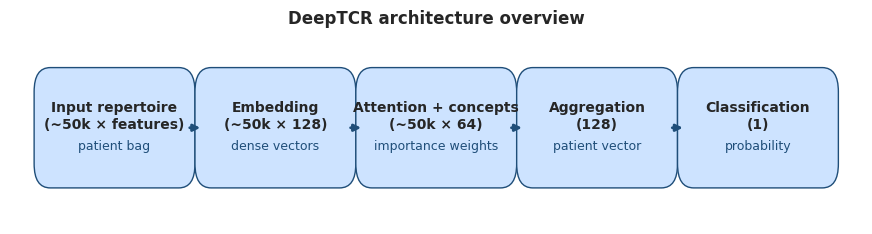

Biology: shows how an entire repertoire collapses to one decision.
CS: every block is differentiable, so the whole pipeline trains end-to-end.


In [13]:
# Conceptual diagram using matplotlib patches
labels = [
    ("Input repertoire\n(~50k × features)", "patient bag"),
    ("Embedding\n(~50k × 128)", "dense vectors"),
    ("Attention + concepts\n(~50k × 64)", "importance weights"),
    ("Aggregation\n(128)", "patient vector"),
    ("Classification\n(1)", "probability")
]
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis('off')
y = 0.5
width = 1.6
height = 0.6
x_positions = np.linspace(0, 8, len(labels))
for (text, subtitle), x in zip(labels, x_positions):
    box = FancyBboxPatch((x, y), width, height, boxstyle="round,pad=0.2", facecolor="#cde3ff", edgecolor="#1f4e79")
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2 + 0.1, text, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.text(x + width / 2, y + 0.15, subtitle, ha='center', va='center', fontsize=9, color="#1f4e79")

for x1, x2 in zip(x_positions[:-1], x_positions[1:]):
    ax.annotate('', xy=(x2 - 0.1, y + height / 2), xytext=(x1 + width + 0.1, y + height / 2),
                arrowprops=dict(arrowstyle='-|>', color='#1f4e79', lw=2))

ax.set_xlim(-0.5, x_positions[-1] + width + 0.5)
ax.set_ylim(0, 1.6)
ax.set_title('DeepTCR architecture overview', fontsize=12, fontweight='bold')
plt.show()
print("Biology: shows how an entire repertoire collapses to one decision.")
print("CS: every block is differentiable, so the whole pipeline trains end-to-end.")

## ✅ Summary: Mateenah’s Architecture Wins

**Biology takeaways**
- You can now cite the Methods section and explain what each block (embedding → attention → aggregation → classification) does.
- Concepts (64 buckets) tie the attention math back to biology (tumor-like vs viral-like motifs) rather than staying abstract.
- The simplified forward pass reused the same patient bags from Days 6–7, so every diagram ties back to actual repertoires.

**Computer-science takeaways**
- You traced tensor shapes through each layer using DataFrames/plots, including a simulated weighted aggregation and sigmoid classifier.
- Multiple random seeds still produced valid probabilities, reminding you how logits → sigmoid becomes a patient-level score.
- The matplotlib diagram is now your mental cheat sheet when someone asks, “What is DeepTCR actually doing?”

**Tie-in to the paper/docs**
- Methods – DeepTCR Architecture: reference it whenever you describe the four-block pipeline or `num_concepts=64`.
- `docs/deeptcr_architecture.md`: mirrors today’s notebook with screenshots you can reuse in your own notes.

**Reflection prompts (write in the Notes section):**
1. Which layer would you tweak if the paper had chosen `num_concepts=128`, and what trade-off would that introduce?
2. How would you explain the difference between “attention weights” and “concept assignments” to your Day‑7 self?
3. Where do the patient-level probabilities reconnect with `response.csv` when you evaluate a model?

**Next Step:** open `Day_09_DeepTCR_Setup/Day_09_DeepTCR_Setup.ipynb` and put this architecture to work.

## 📝 Notes Section

Write down:
- What each layer does (in your own words)
- How attention works (conceptually)
- What "concepts" are (your understanding)
- Questions you still have